# ZZU Transformations — Synthetic Pipeline (head-to-tail)

This notebook runs the **entire synthetic-side pipeline in one place**, mirroring [WALKTHROUGH.md](WALKTHROUGH.md). It generates the five synthetic datasets, renders all pedagogical figures, runs the main accuracy benchmark, the cost analysis, and the ZZU inner-method ablation — every figure and CSV referenced in the writeup.

**Scope.** Synthetic only. Real-world experiments live in [concrete_analysis.ipynb](concrete_analysis.ipynb) and [bike_analysis.ipynb](bike_analysis.ipynb).

**Runtime.** ~3–6 minutes total on a modern laptop.

**Outputs.** Everything lands in `notebook_outputs/` so the canonical [comparison_results/](comparison_results/), [generated_datasets/](generated_datasets/), and [synthetic_visualizations/](synthetic_visualizations/) folders are untouched.

## 1. Setup

The two env-var hooks documented in §2 of the walk-through:

- `REPRODUCE_BASE_DIR` — redirects every script's outputs into the sandbox folder
- `REPRODUCE_DATASETS=all` — overrides the 3-dataset development default to sweep all five datasets

In [1]:
import os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
SANDBOX = PROJECT_ROOT / "notebook_outputs"
SANDBOX.mkdir(exist_ok=True)

os.environ["REPRODUCE_BASE_DIR"] = str(SANDBOX)
os.environ["REPRODUCE_DATASETS"] = "all"

# Make the scripts/ package importable as a flat namespace
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

print(f"Project root:       {PROJECT_ROOT}")
print(f"Notebook sandbox:   {SANDBOX}")
print(f"Reproduce datasets: {os.environ['REPRODUCE_DATASETS']}")

Project root:       /weka/scratch/dkhasha1/bzhang90/zzu-transformations
Notebook sandbox:   /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs
Reproduce datasets: all


## 2. Reproducibility primitives

Every randomness source flows through `np.random.default_rng(seed)`. Default seeds and split sizes live in [scripts/reproducibility.py](scripts/reproducibility.py).

In [2]:
import reproducibility

print(f"N_SEEDS              = {reproducibility.N_SEEDS}")
print(f"TEST_FRACTION        = {reproducibility.TEST_FRACTION}")
print(f"DEFAULT_SEED         = {reproducibility.DEFAULT_SEED}")
print(f"ZZU_VALIDATION_SEED  = {reproducibility.ZZU_VALIDATION_SEED}")
print(f"DATASET_SEEDS        = {reproducibility.DATASET_SEEDS}")

N_SEEDS              = 10
TEST_FRACTION        = 0.2
DEFAULT_SEED         = 123
ZZU_VALIDATION_SEED  = 0
DATASET_SEEDS        = {'exponential_multiplicative': 101, 'exponential_additive': 102, 'michaelis_menten': 103, 'logistic_growth': 104, 'multivariable_nonlinear': 105}


## 3. Algorithm library — sanity check

Quick demo on `exponential_multiplicative` to confirm all three method families recover the true `(a, b) = (2, 0.7)`.

In [3]:
import transformation_algorithms as ta
import toy_data as td

bundle = td.make_exponential_multiplicative()
X, y = bundle.X.values, bundle.y.values
X_tr, X_te, y_tr, y_te = ta.train_test_split_arrays(X, y, test_size=0.2, seed=0)

# Linearized OLS
linear = ta.TransformedOLS(transform="log", use_smearing=True).fit(X_tr, y_tr)

# Direct nonlinear (BFGS)
model_fn = lambda X, t: t[0] * np.exp(t[1] * X[:, 0])
theta_init = np.array([1.0, 0.1])
bfgs = ta.BFGSRegressor(model_fn=model_fn).fit(X_tr, y_tr, theta_init)

# Hybrid (ZZU)
zzu = ta.ZZUTransformRegressor(
    model_fn=model_fn,
    coeff_to_init=lambda m: np.array([np.exp(m.beta_[0]), m.beta_[1]]),
    transformations={"log_smear": ta.TransformedOLS(transform="log", use_smearing=True)},
    fallback_theta_init=theta_init,
).fit(X_tr, y_tr)

rows = [
    ("log_smear", ta.regression_metrics(y_te, linear.predict(X_te))["rmse"], linear.beta_),
    ("BFGS",      ta.regression_metrics(y_te, bfgs.predict(X_te))["rmse"],   bfgs.theta_),
    ("ZZU",       ta.regression_metrics(y_te, zzu.predict(X_te))["rmse"],    zzu.nonlinear_regressor_.theta_),
]
print(f"{'method':10s}  {'RMSE':>7s}    parameters")
print("-" * 60)
for name, rmse, params in rows:
    print(f"{name:10s}  {rmse:7.3f}    {np.array2string(np.asarray(params), precision=3)}")
print(f"\nTrue params: a=2.0, b=0.7")

method         RMSE    parameters
------------------------------------------------------------
log_smear     9.234    [0.733 0.682]
BFGS          9.602    [1.942 0.712]
ZZU           9.619    [1.942 0.712]

True params: a=2.0, b=0.7


/tmp/ipykernel_1730686/3936575956.py:12: RuntimeWarning: overflow encountered in exp
  model_fn = lambda X, t: t[0] * np.exp(t[1] * X[:, 0])
/tmp/ipykernel_1730686/3936575956.py:12: RuntimeWarning: overflow encountered in multiply
  model_fn = lambda X, t: t[0] * np.exp(t[1] * X[:, 0])
/weka/scratch/dkhasha1/bzhang90/zzu-transformations/scripts/transformation_algorithms.py:1156: RuntimeWarning: overflow encountered in square
  return float(np.sum(r ** 2)) / len(y)


## 4. Generate the five synthetic datasets

CSVs land in `notebook_outputs/generated_datasets/`.

In [4]:
import toy_data
toy_data.main()

for name in ["exponential_multiplicative", "exponential_additive",
             "michaelis_menten", "logistic_growth", "multivariable_nonlinear"]:
    df = pd.read_csv(SANDBOX / "generated_datasets" / f"{name}.csv")
    display(Markdown(f"**[{name}]**  shape = {df.shape}"))
    display(df.head(3))

                              n  p     y_mean      y_std     y_min  \
name                                                                 
exponential_multiplicative  120  1  18.522305  18.446324  1.238502   
exponential_additive        120  1  18.552552  17.517701  0.000001   
michaelis_menten            120  1   7.615947   1.875816  0.794716   
logistic_growth             140  1  50.422403  40.911348 -2.026761   
multivariable_nonlinear     500  3  47.762507  28.563559 -1.009150   

                                 y_max                noise_type  seed  
name                                                                    
exponential_multiplicative   85.281794  multiplicative_lognormal   101  
exponential_additive         68.347441         additive_gaussian   102  
michaelis_menten              9.539293         additive_gaussian   103  
logistic_growth             105.584019         additive_gaussian   104  
multivariable_nonlinear     115.728821         additive_gaussian   105 

**[exponential_multiplicative]**  shape = (120, 3)

,x,y,y_true
0,0.000000,1.641498,2.000000
1,0.042017,1.238502,2.059697
2,0.084034,2.466490,2.121176


**[exponential_additive]**  shape = (120, 3)

,x,y,y_true
0,0.000000,5.128647,2.000000
1,0.042017,12.881324,2.059697
2,0.084034,6.898879,2.121176


...

,x,y,y_true
0,0.100000,0.807195,0.476190
1,0.267227,0.794716,1.178651
2,0.434454,1.979050,1.784605


**[logistic_growth]**  shape = (140, 3)

,x,y,y_true
0,0.000000,1.933612,0.247262
1,0.071942,1.950099,0.269497
2,0.143885,-1.573645,0.293726


**[multivariable_nonlinear]**  shape = (500, 5)

,x1,x2,x3,y,y_true
0,3.190977,3.043263,0.602650,31.344704,29.333900
1,4.957299,4.927363,1.470958,43.775906,51.387642
2,0.483647,1.898272,0.603067,16.677677,16.511112


## 5. Visualize the synthetic datasets

One PNG per 1D dataset, plus a 2×2 overview grid, plus marginal scatter for the multivariable case.

### 2×2 overview

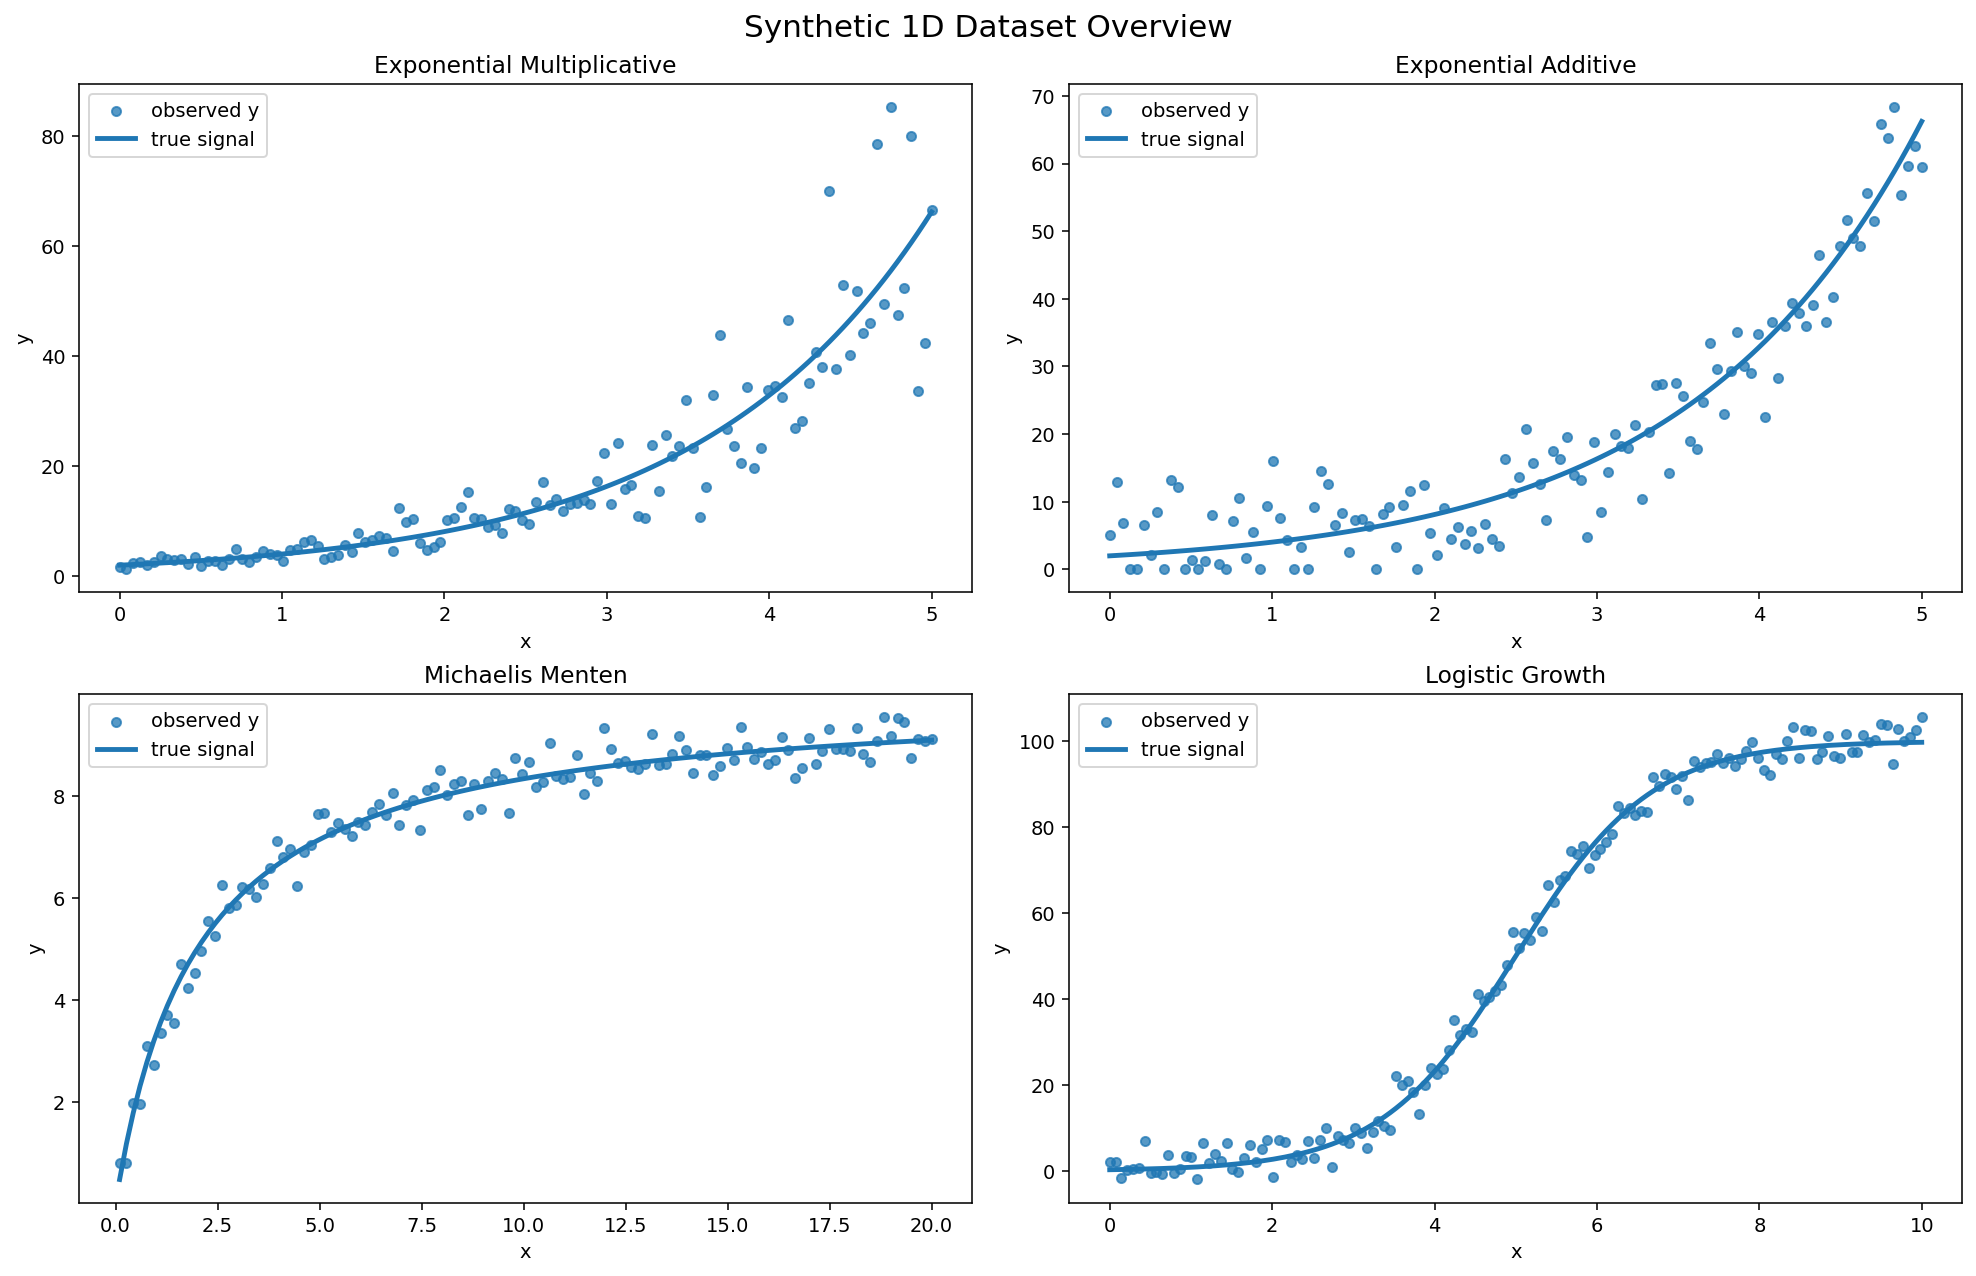

### Multivariable marginals

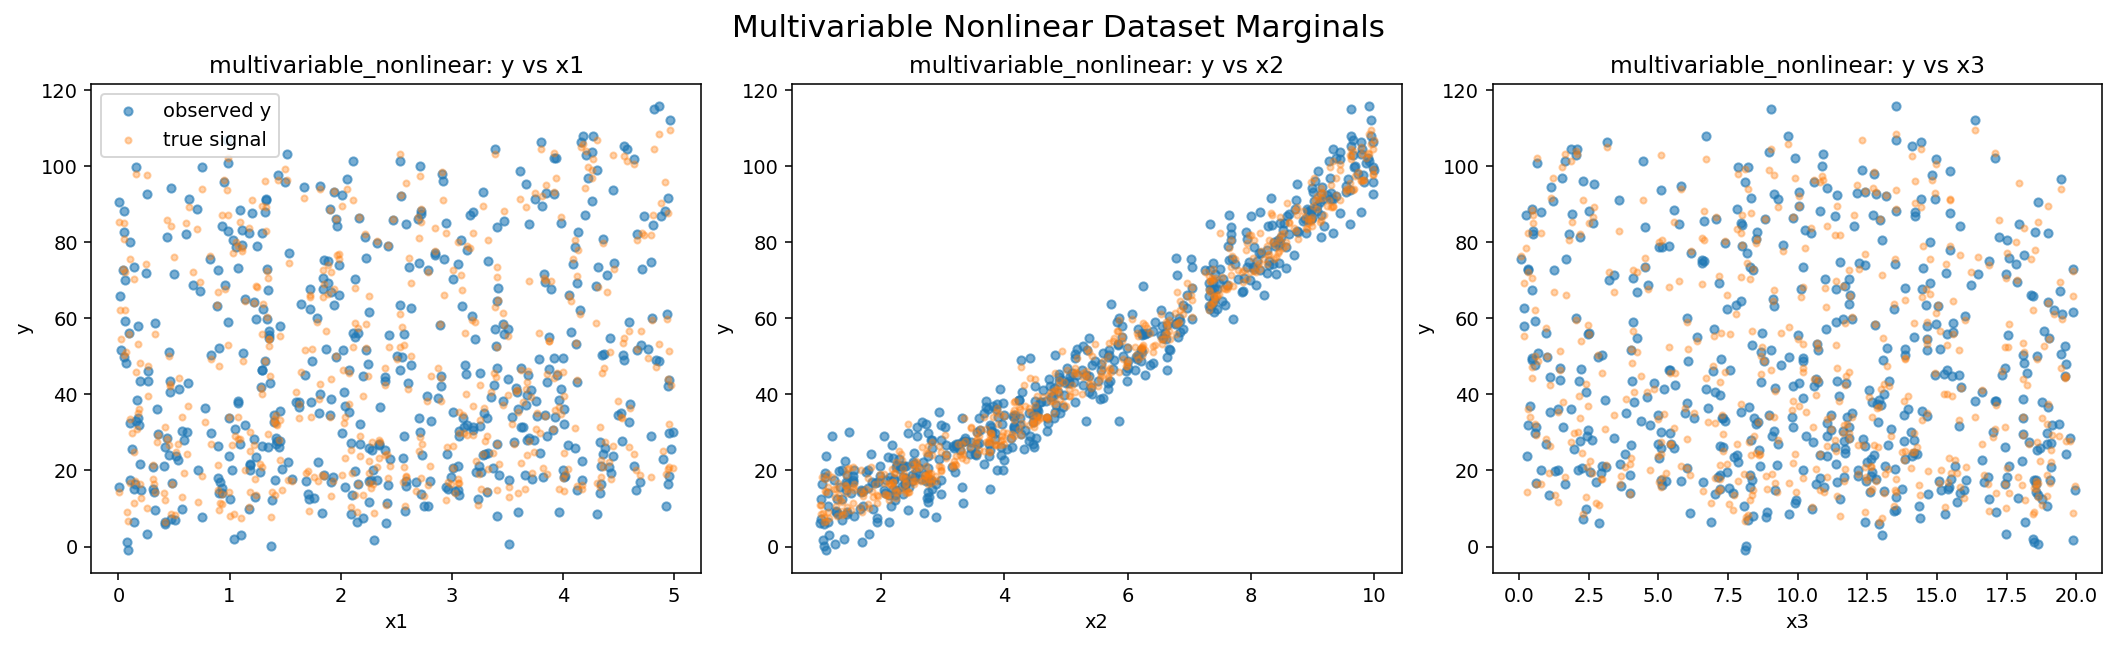

In [5]:
import visualize_synthetic_data as vsd

out_dir = SANDBOX / "synthetic_visualizations"
out_dir.mkdir(parents=True, exist_ok=True)
suite = td.generate_default_suite()
vsd.save_overview_grid(suite, out_dir, dpi=140)
vsd.save_individual_one_dimensional_plots(suite, out_dir, dpi=140)
vsd.save_multivariable_plot(suite, out_dir, dpi=140)

display(Markdown("### 2×2 overview"))
display(Image(filename=str(out_dir / "synthetic_data_overview.png")))
display(Markdown("### Multivariable marginals"))
display(Image(filename=str(out_dir / "multivariable_nonlinear_marginals.png")))

## 6. Pedagogical figure — linearization diagnostics

Three figures showing how response transformations interact with different noise structures (`exp_mult`, `exp_add`, Michaelis–Menten). See WALKTHROUGH §6 for what to read off each panel.

Wrote /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/lin_fits_original.png
Wrote /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/lin_transformed_scale.png
Wrote /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/lin_residuals.png

Three figures written to comparison_results/.


### Original-scale fits (which curve hugs the data?)

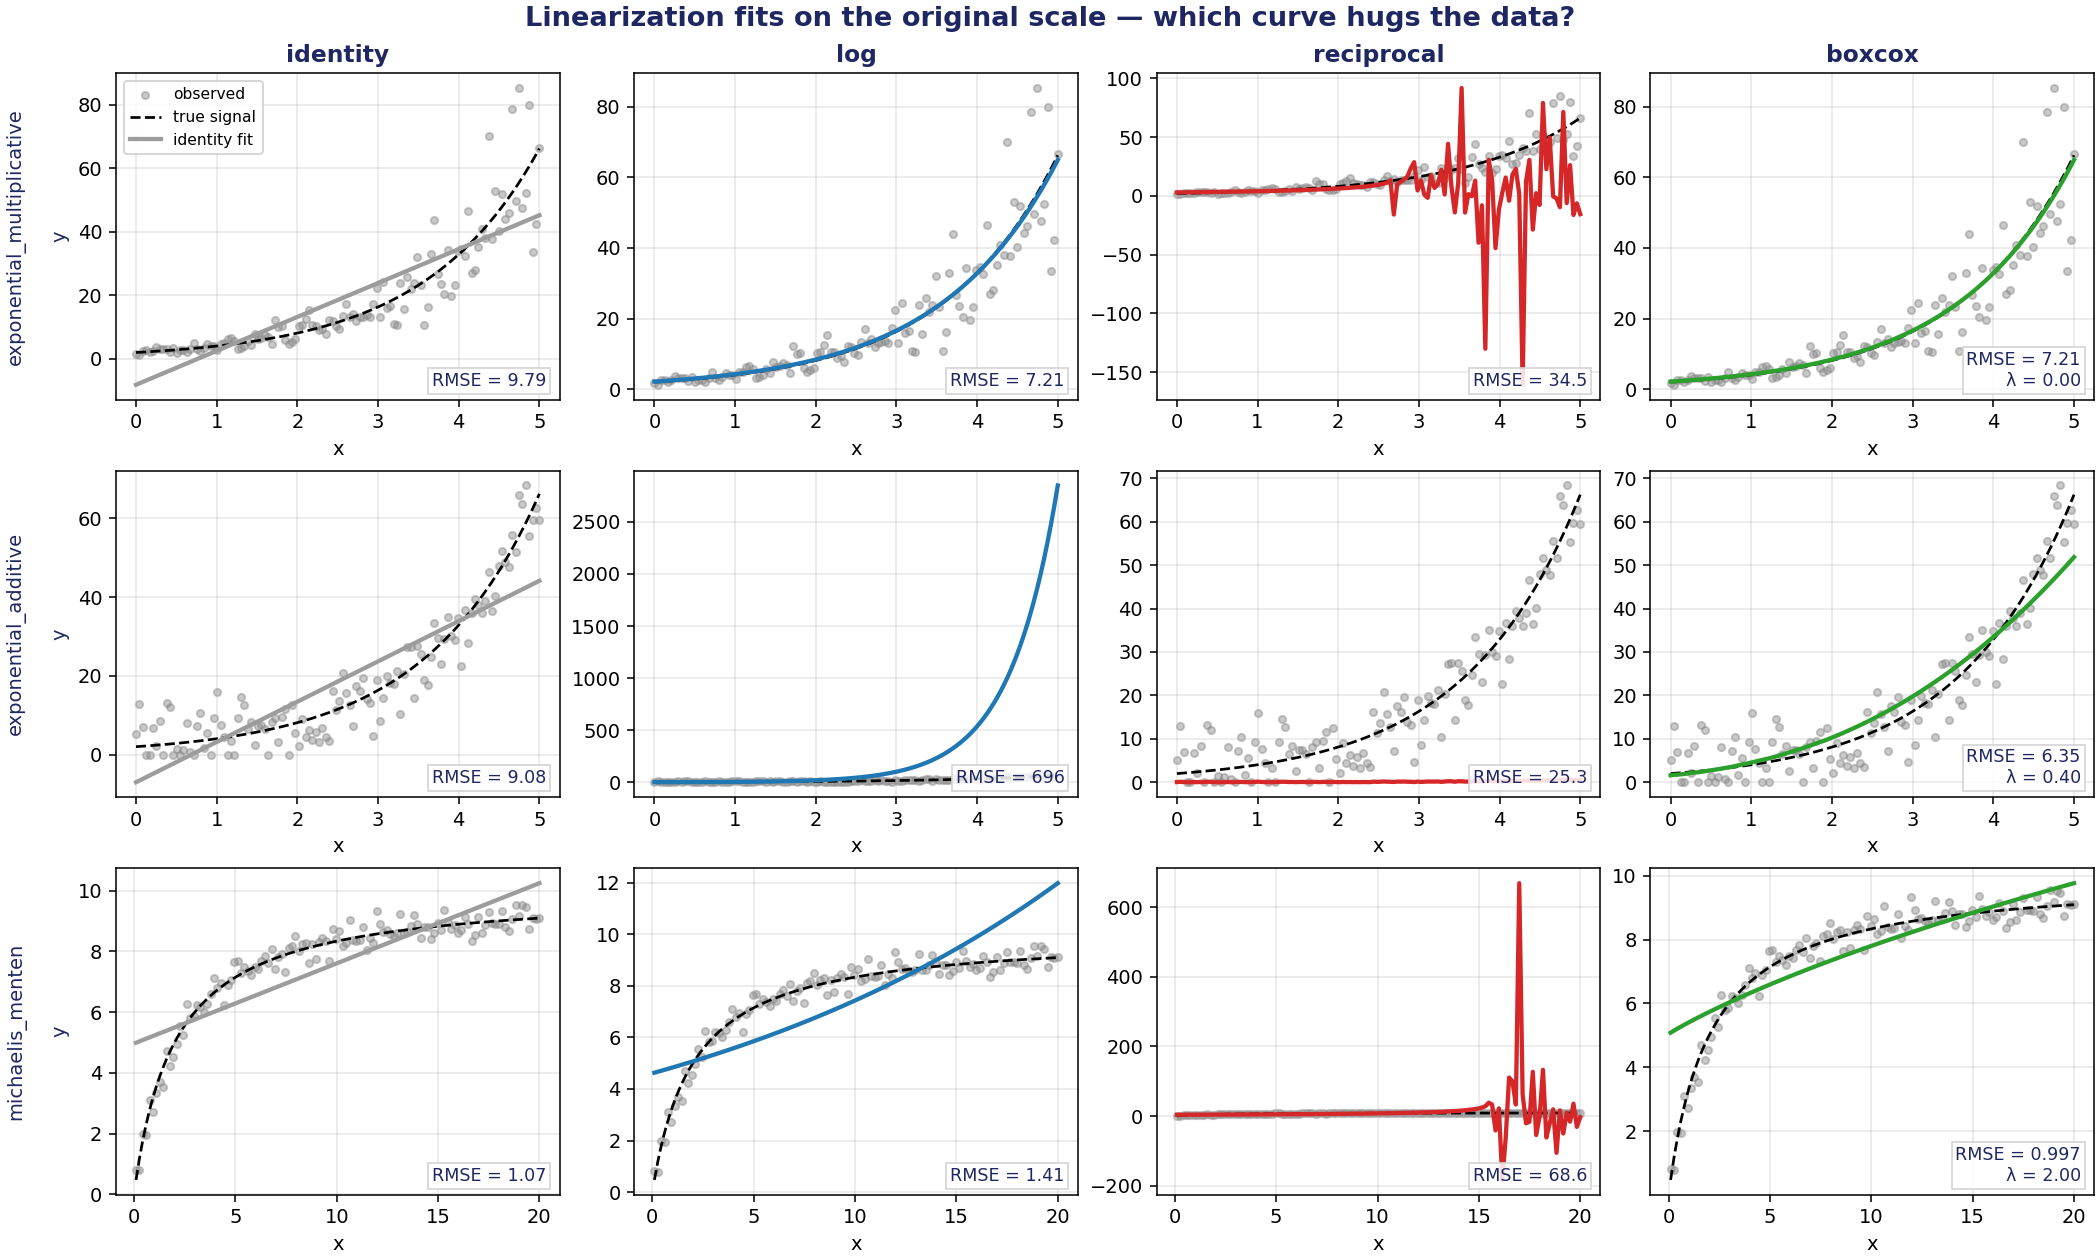

### Transformed-scale linearity (does T(y) vs x become straight?)

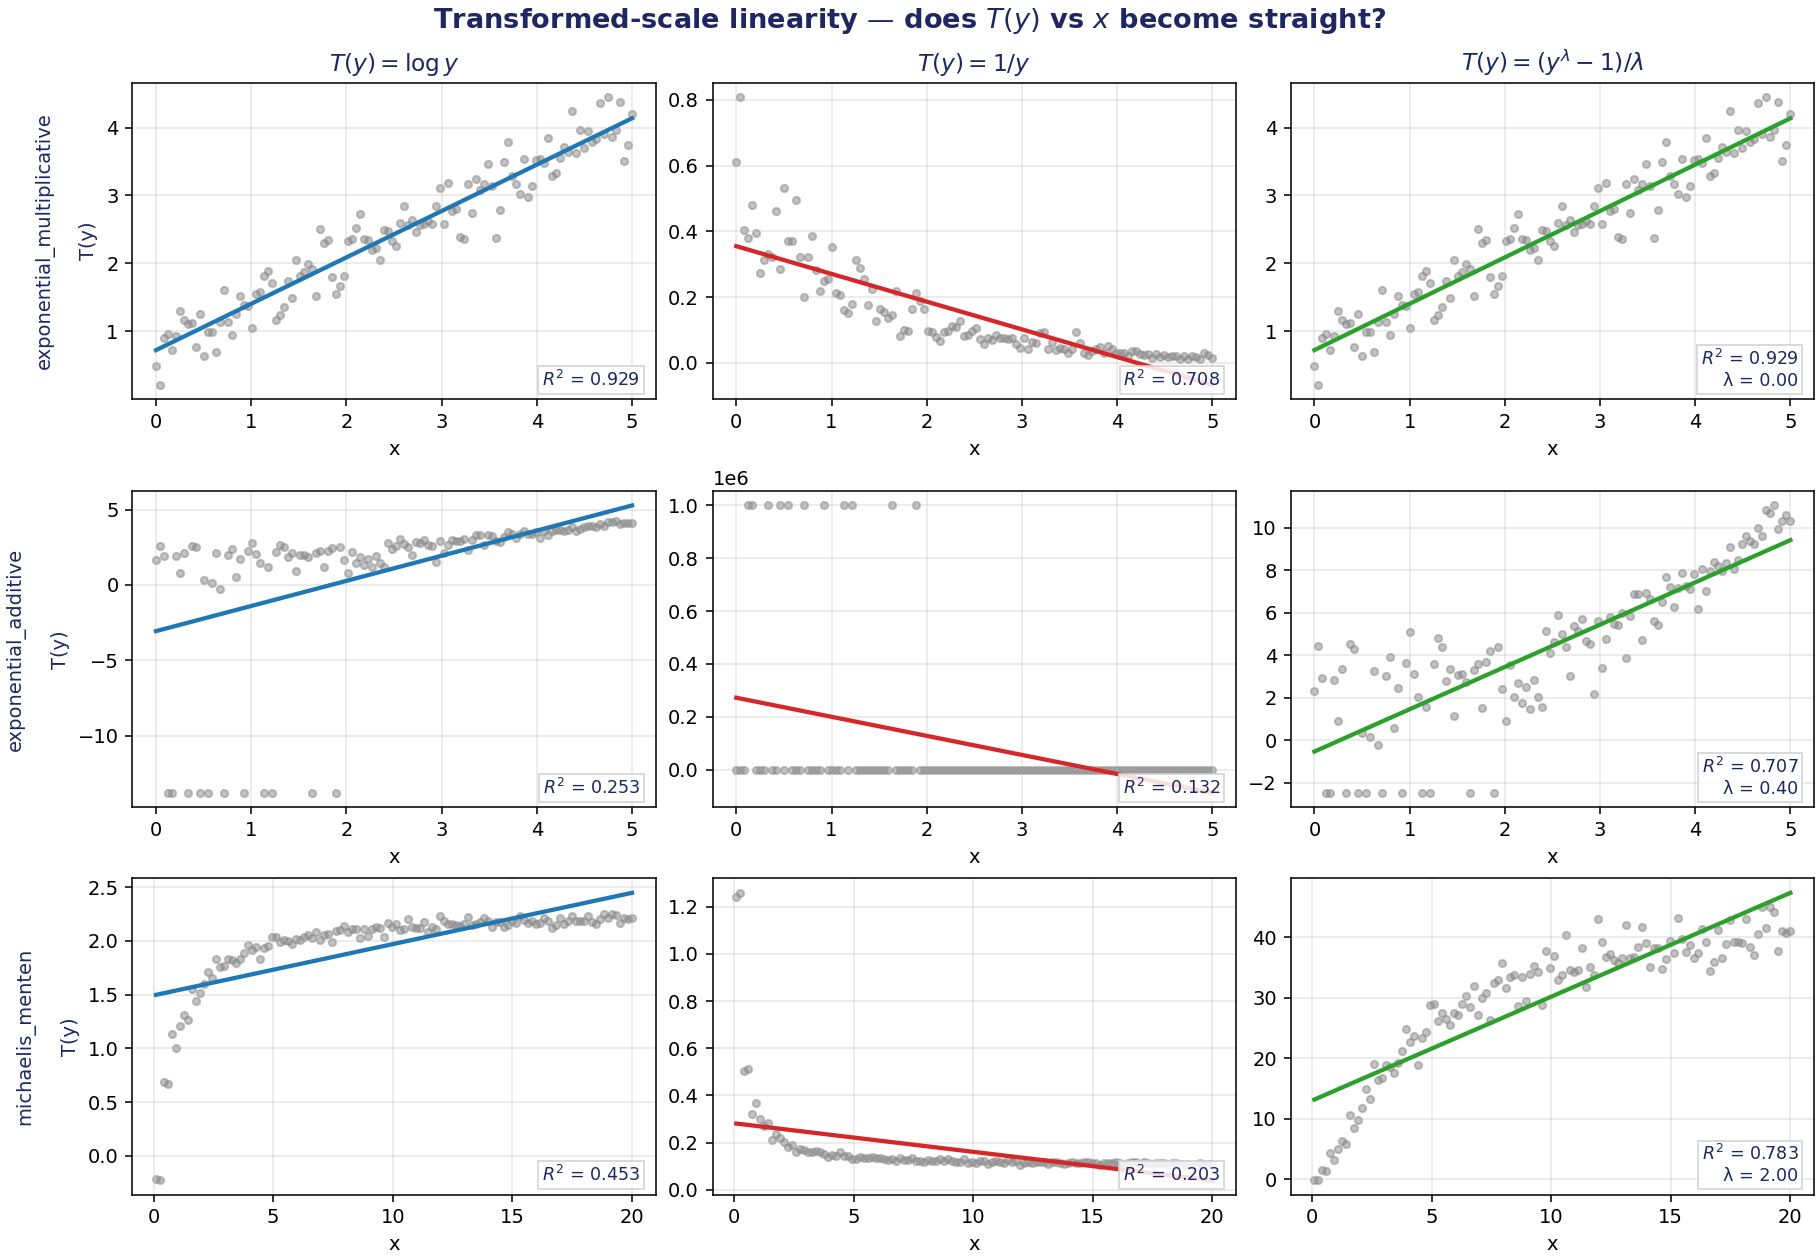

### Transformed-scale residuals (does the OLS assumption hold?)

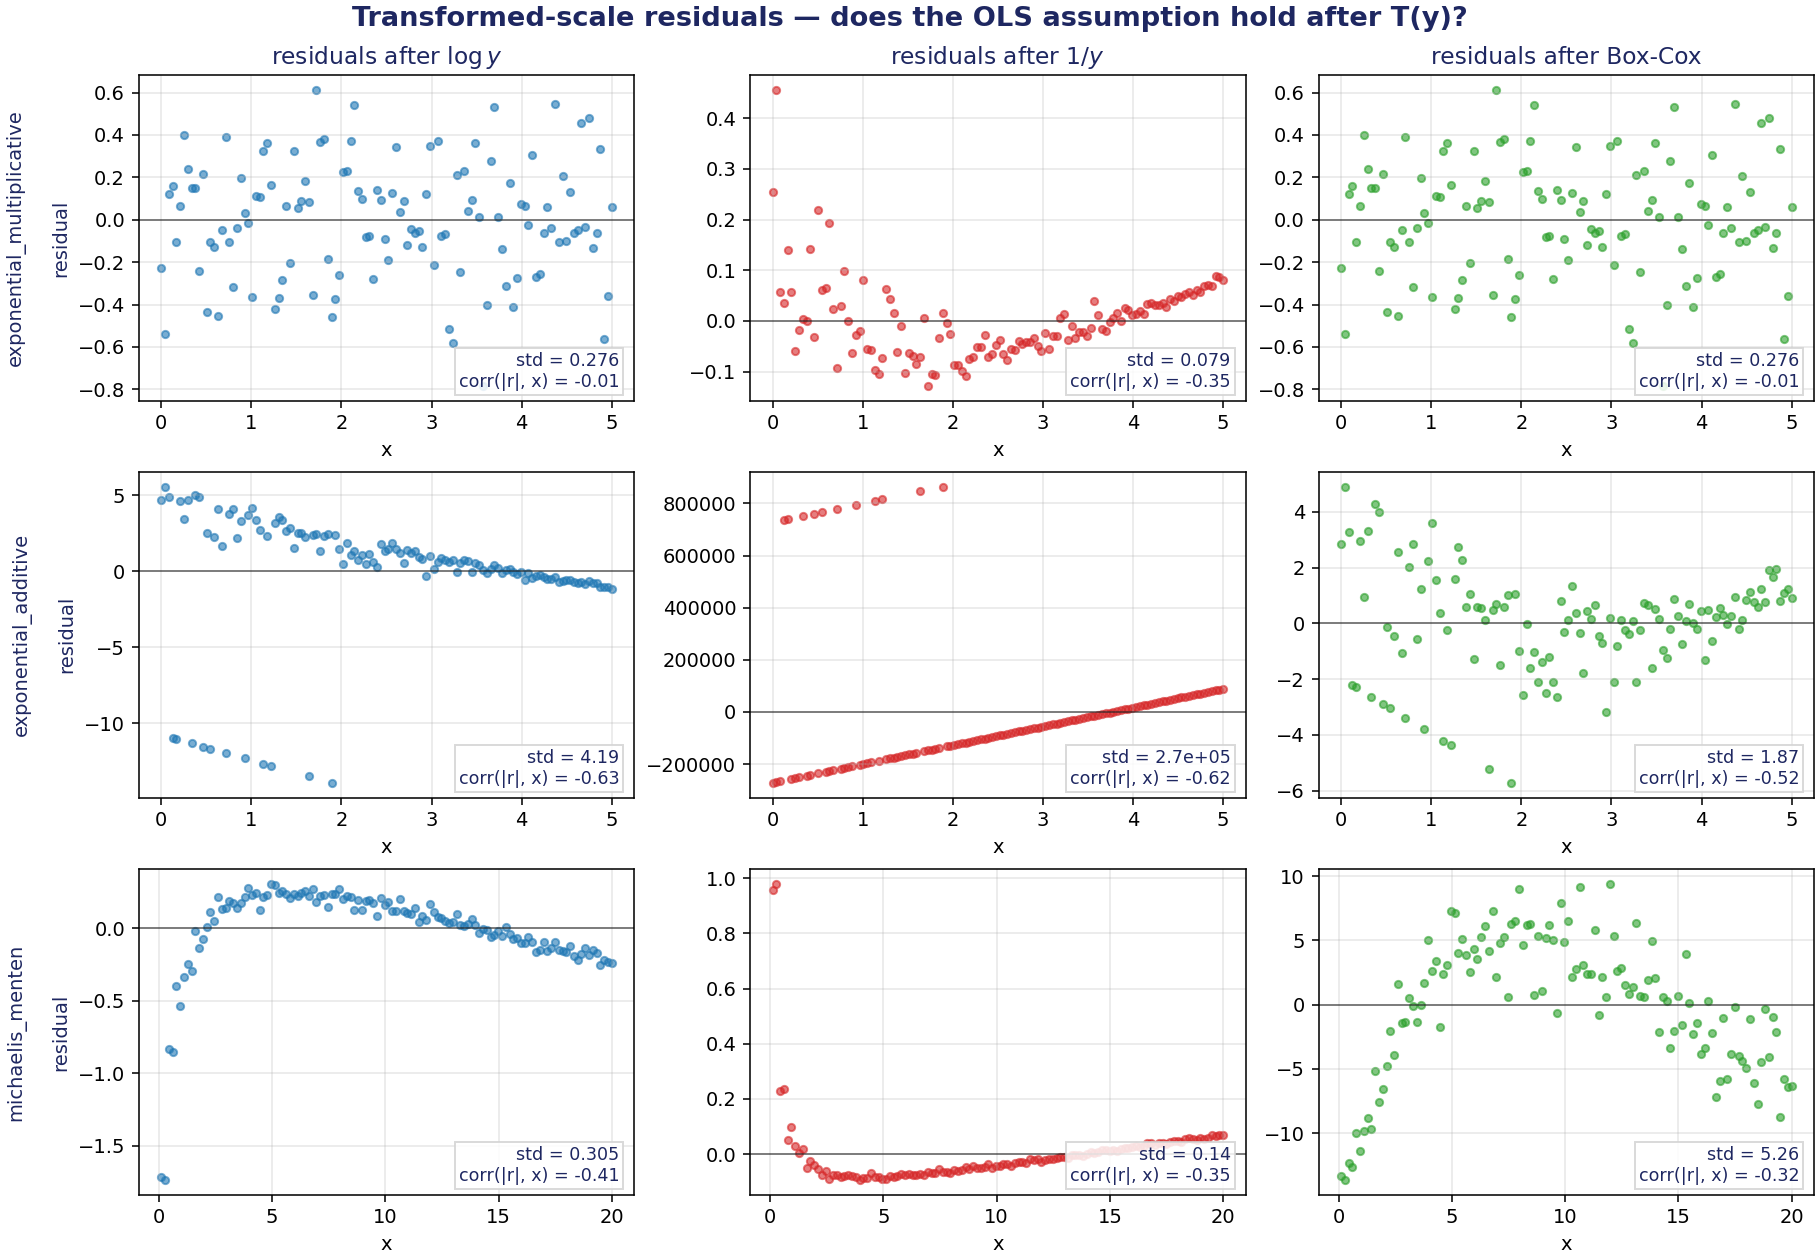

In [6]:
import build_linearization_figures
build_linearization_figures.main()

cr = SANDBOX / "comparison_results"
display(Markdown("### Original-scale fits (which curve hugs the data?)"))
display(Image(filename=str(cr / "lin_fits_original.png")))
display(Markdown("### Transformed-scale linearity (does T(y) vs x become straight?)"))
display(Image(filename=str(cr / "lin_transformed_scale.png")))
display(Markdown("### Transformed-scale residuals (does the OLS assumption hold?)"))
display(Image(filename=str(cr / "lin_residuals.png")))

## 7. Pedagogical figure — optimizer trajectories

Two parameters → 2D SSE contour with GD / GN / BFGS trajectories overlaid. The qualitative differences become immediately legible.

/weka/scratch/dkhasha1/bzhang90/zzu-transformations/scripts/build_optimizer_trajectories.py:44: RuntimeWarning: overflow encountered in exp
  return a * np.exp(b * x)
/weka/scratch/dkhasha1/bzhang90/zzu-transformations/scripts/build_optimizer_trajectories.py:48: RuntimeWarning: overflow encountered in square
  return float(np.sum((y - f(theta)) ** 2))
/weka/scratch/dkhasha1/bzhang90/zzu-transformations/scripts/build_optimizer_trajectories.py:44: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(b * x)


Wrote /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/optimizer_trajectories.png
  GD:   400 steps,  final θ = [1.26003496 0.80074361]
  GN:   8 steps,  final θ = [2.16736327 0.67931922]
  BFGS: 40 steps,  final θ = [2.16736388 0.6793192 ]


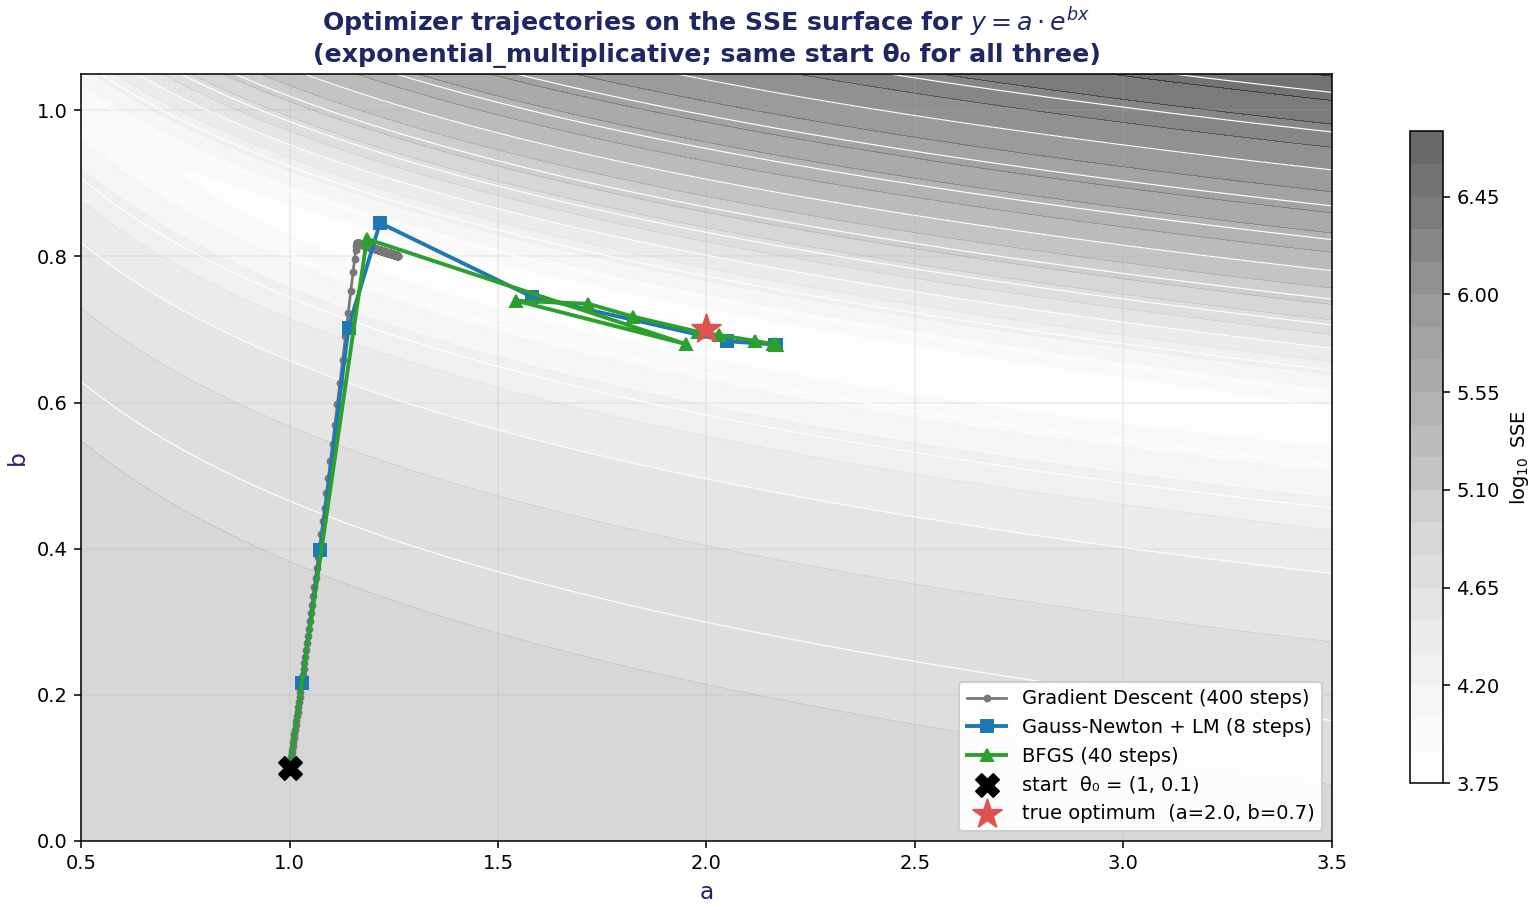

In [7]:
import build_optimizer_trajectories
build_optimizer_trajectories.main()

display(Image(filename=str(SANDBOX / "comparison_results" / "optimizer_trajectories.png")))

## 8. Main accuracy benchmark

11 transformed-OLS variants + GD / GN / BFGS + ZZU across all 5 datasets, 10 random 80/20 splits each. ~30 seconds.

[exponential_multiplicative] n=120, p=1
[exponential_additive] n=120, p=1
[michaelis_menten] n=120, p=1
[logistic_growth] n=140, p=1
[multivariable_nonlinear] n=500, p=3
Wrote 750 rows to /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/raw_results.csv
Wrote summary to /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/summary_by_method.csv
Wrote plots to /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/

Top 3 methods (by mean test RMSE) per dataset:

[exponential_multiplicative]
          method         family  mean_rmse  std_rmse  mean_r2  frac_converged
       log_smear linearized_ols   7.581126  2.498141 0.808197             NaN
yeojohnson_smear linearized_ols   7.620045  2.543802 0.807597             NaN
    boxcox_smear linearized_ols   7.656648  2.567911 0.807402             NaN

[exponential_additive]
method    family  mean_rmse  std_rmse  mean_r2  frac_converged


### Top-3 methods per dataset (by mean test RMSE)

**[exponential_additive]**

,method,family,mean_rmse,mean_r2,frac_converged
0,GD,nonlinear,5.136741,0.904627,0.0
1,BFGS,nonlinear,5.142041,0.904417,1.0
2,GN,nonlinear,5.142041,0.904417,1.0


**[exponential_multiplicative]**

...

**[michaelis_menten]**

,method,family,mean_rmse,mean_r2,frac_converged
0,BFGS,nonlinear,0.296731,0.969784,1.0
1,GN,nonlinear,0.296731,0.969784,1.0
2,ZZU,zzu_hybrid,0.296763,0.969798,1.0


**[multivariable_nonlinear]**

,method,family,mean_rmse,mean_r2,frac_converged
0,ZZU,zzu_hybrid,4.653986,0.973279,1.0
1,GN,nonlinear,4.745290,0.972444,1.0
2,BFGS,nonlinear,4.745290,0.972444,1.0


### RMSE by method (one panel per dataset)

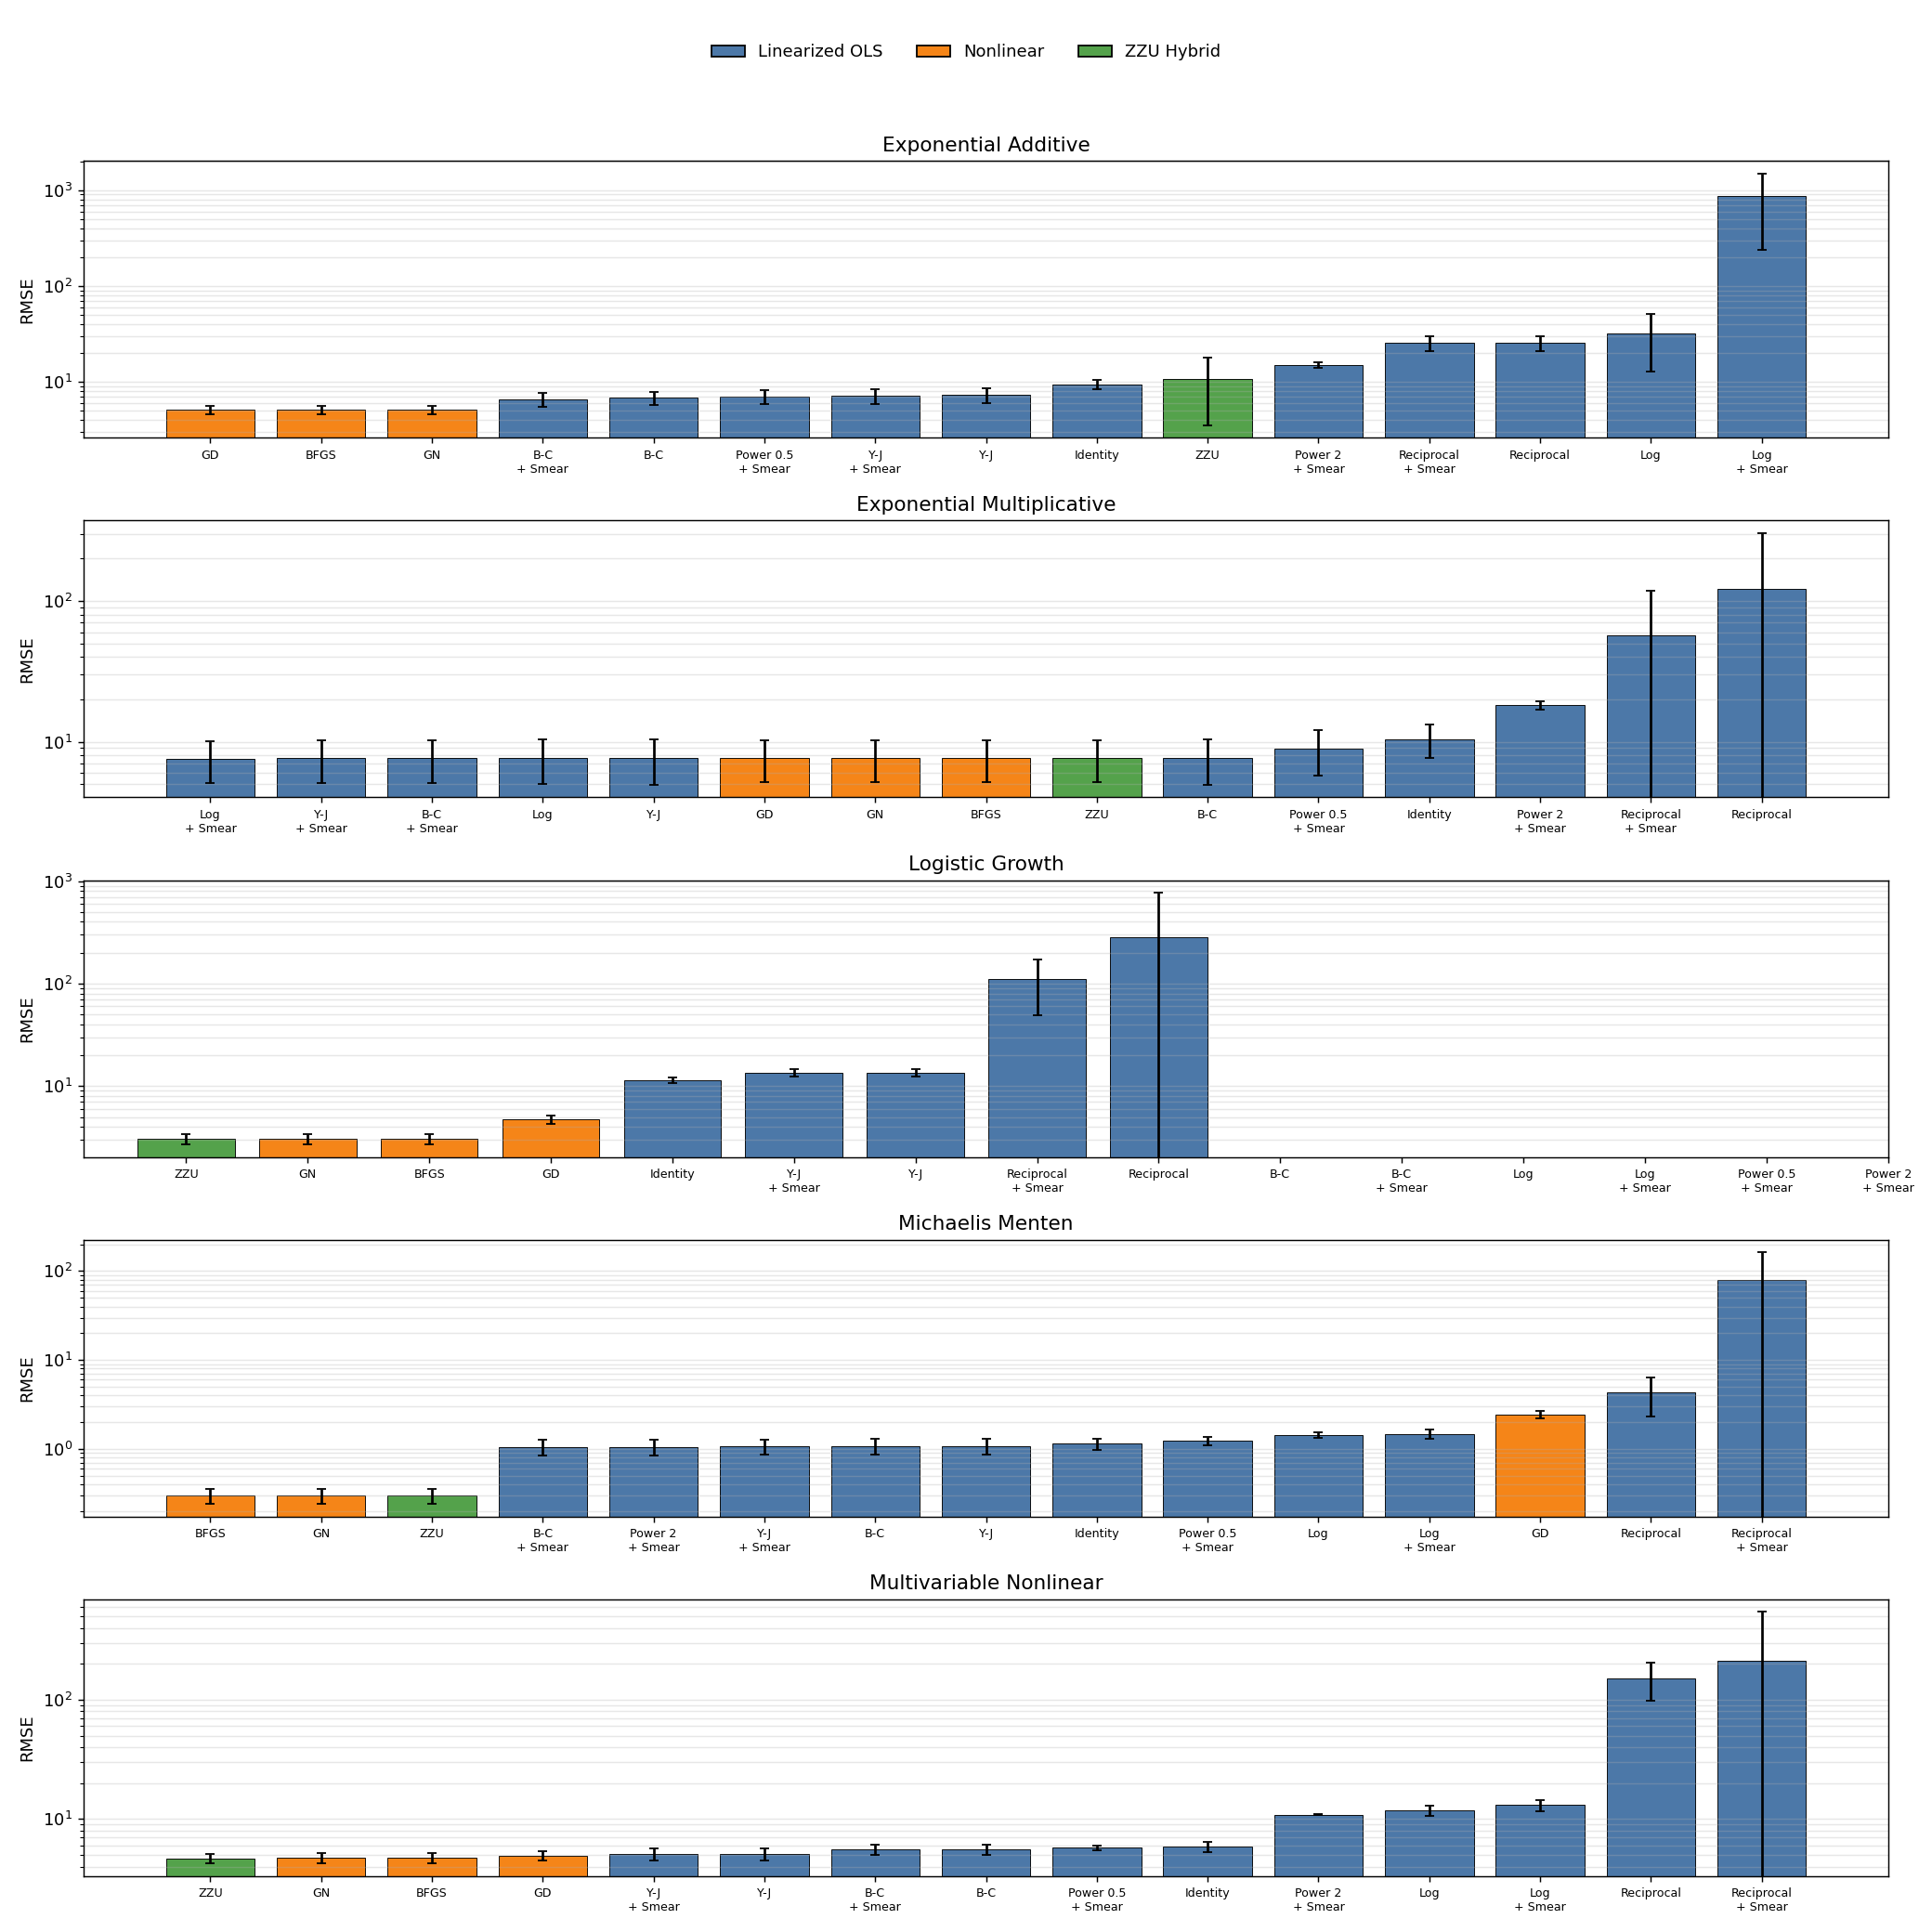

### Best-fit overlays (1D datasets, seed 0)

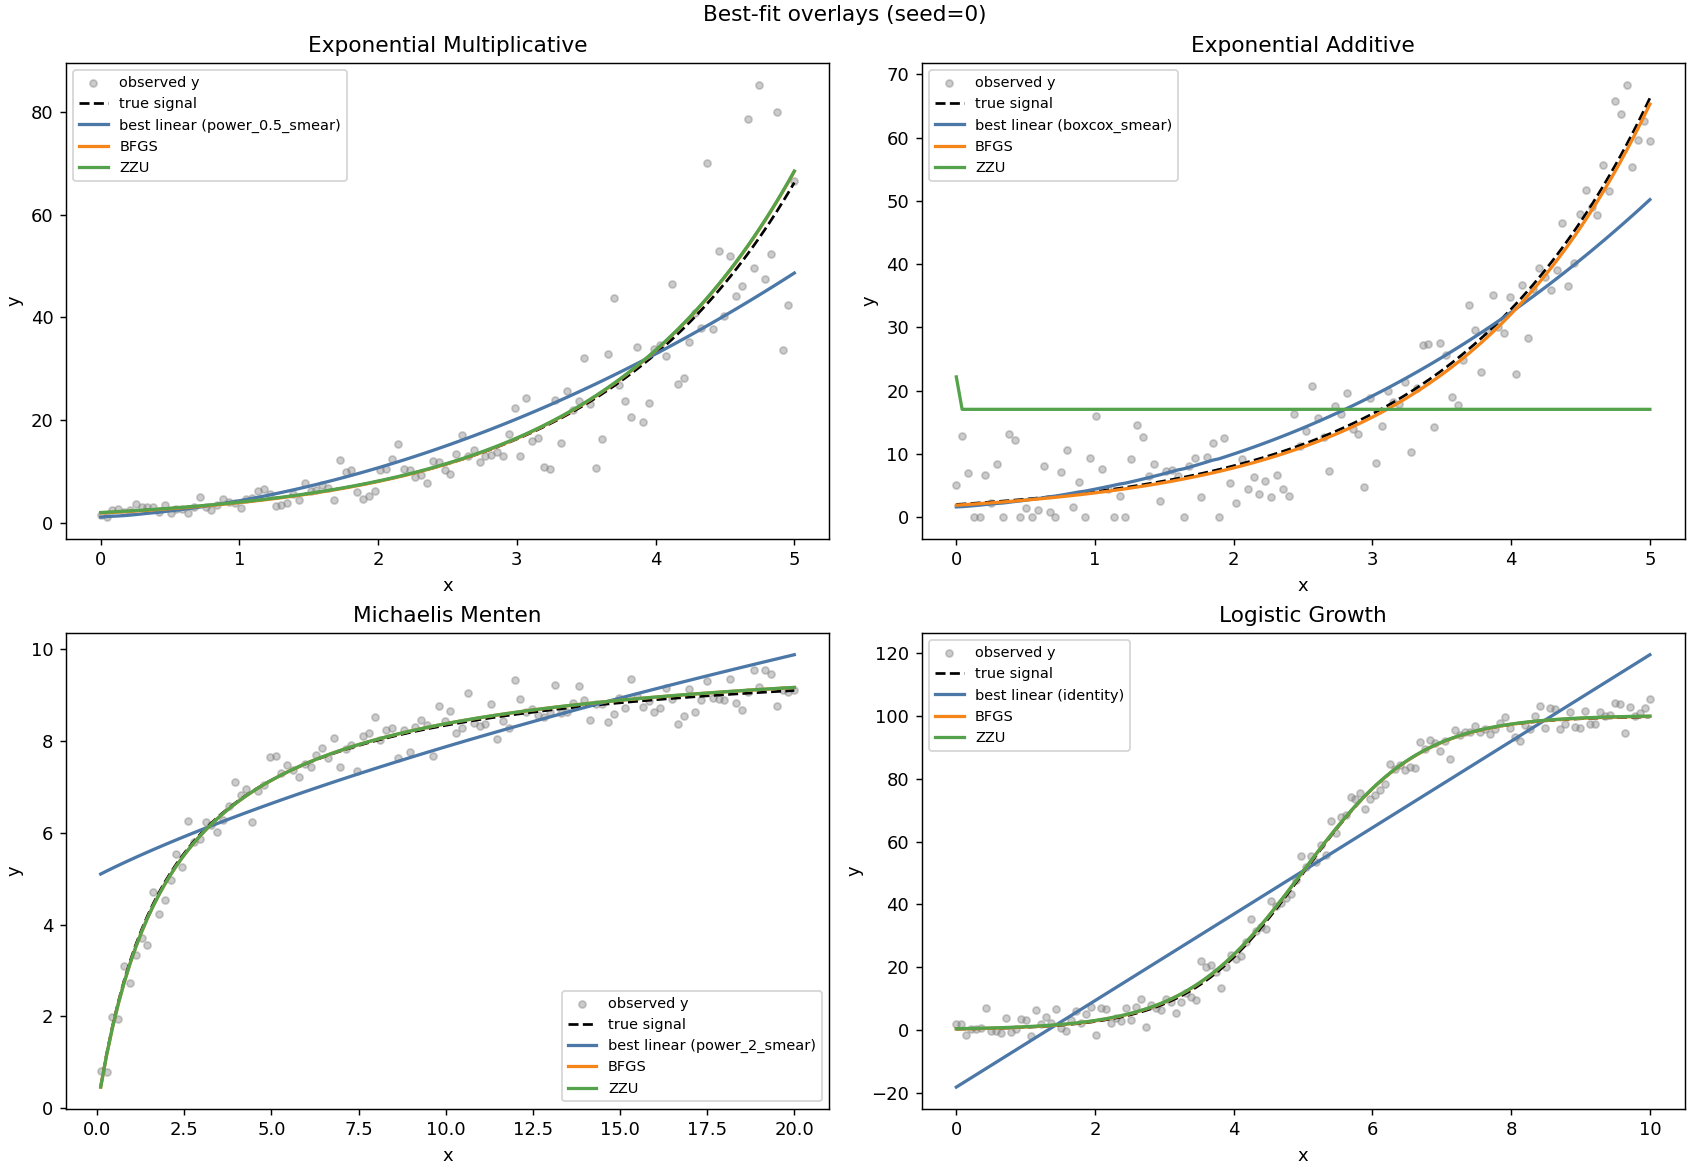

In [8]:
import run_comparison
t0 = time.perf_counter()
run_comparison.main()
print(f"\nElapsed: {time.perf_counter() - t0:.1f}s")

summary = pd.read_csv(SANDBOX / "comparison_results" / "summary_by_method.csv")
display(Markdown("### Top-3 methods per dataset (by mean test RMSE)"))
for d in summary.dataset.unique():
    sub = summary[(summary.dataset == d) & summary.mean_rmse.notna()].nsmallest(3, "mean_rmse")
    display(Markdown(f"**[{d}]**"))
    display(sub[["method","family","mean_rmse","mean_r2","frac_converged"]].reset_index(drop=True))

display(Markdown("### RMSE by method (one panel per dataset)"))
display(Image(filename=str(SANDBOX / "comparison_results" / "rmse_by_method.png")))

display(Markdown("### Best-fit overlays (1D datasets, seed 0)"))
display(Image(filename=str(SANDBOX / "comparison_results" / "fit_overlay.png")))

## 9. Cost analysis

Wall-clock time, optimizer iterations, and model_fn evaluations per fit. Adds the `BFGS_warmstart` row to isolate "is the warm-start init helpful?" from "does the screening overhead pay off?" ~2 minutes.

> **Note on `mean_fit_time_sec` (wall-clock vs deterministic cost).** Fit time is measured with `time.perf_counter()`, so it varies run-to-run with CPU load — typically 5–20% on long fits (GD), higher relative jitter on sub-millisecond fits (BFGS/GN). Iteration counts and `mean_n_model_evals` are deterministic up to 1-ULP propagation in the dataset. For cost comparisons that need to be **stable across runs use `mean_n_model_evals`** — the work count (number of `model_fn` calls, which captures Jacobian work since each numerical Jacobian costs `2p` calls). The relative ranking between method families is preserved either way (GD is always ~100× slower than BFGS, ZZU's overhead over BFGS is always ~2–3×), but absolute milliseconds will shift between runs.

[exponential_multiplicative] n=120, p=1
[exponential_additive] n=120, p=1
[michaelis_menten] n=120, p=1
[logistic_growth] n=140, p=1
[multivariable_nonlinear] n=500, p=3
Wrote 770 rows to /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/cost_results.csv
Wrote summary to /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/cost_summary.csv
Wrote plots to /weka/scratch/dkhasha1/bzhang90/zzu-transformations/notebook_outputs/comparison_results/
  - cost_pareto_exponential_additive.png
  - cost_pareto_exponential_multiplicative.png
  - cost_pareto_logistic_growth.png
  - cost_pareto_michaelis_menten.png
  - cost_pareto_multivariable_nonlinear.png

Mean cost per method (cheapest 5 per dataset):

[exponential_multiplicative]
             method         family  mean_rmse  mean_fit_time_sec  mean_n_iter  mean_n_model_evals
      power_2_smear linearized_ols  18.127854           0.000041          NaN                 NaN
  

### Cheapest 5 methods per dataset (mean fit time, asc)

**[exponential_additive]**

,method,family,mean_rmse,mean_fit_time_sec,mean_n_iter,mean_n_model_evals
0,reciprocal_smear,linearized_ols,25.591601,0.000040,NaN,NaN
1,log_smear,linearized_ols,865.391631,0.000042,NaN,NaN
2,power_2_smear,linearized_ols,15.076605,0.000042,NaN,NaN
3,power_0.5_smear,linearized_ols,7.108370,0.000044,NaN,NaN
4,reciprocal_no_smear,linearized_ols,25.591610,0.000046,NaN,NaN


**[exponential_multiplicative]**

...

**[michaelis_menten]**

,method,family,mean_rmse,mean_fit_time_sec,mean_n_iter,mean_n_model_evals
0,reciprocal_smear,linearized_ols,79.114311,0.000041,NaN,NaN
1,power_2_smear,linearized_ols,1.057715,0.000042,NaN,NaN
2,power_0.5_smear,linearized_ols,1.233743,0.000045,NaN,NaN
3,log_smear,linearized_ols,1.479098,0.000046,NaN,NaN
4,reciprocal_no_smear,linearized_ols,4.307146,0.000046,NaN,NaN


**[multivariable_nonlinear]**

,method,family,mean_rmse,mean_fit_time_sec,mean_n_iter,mean_n_model_evals
0,log_smear,linearized_ols,13.126348,0.000061,NaN,NaN
1,reciprocal_smear,linearized_ols,213.602767,0.000062,NaN,NaN
2,power_2_smear,linearized_ols,10.862937,0.000072,NaN,NaN
3,log_no_smear,linearized_ols,11.832137,0.000074,NaN,NaN
4,reciprocal_no_smear,linearized_ols,151.870338,0.000076,NaN,NaN


### Cost vs accuracy Pareto

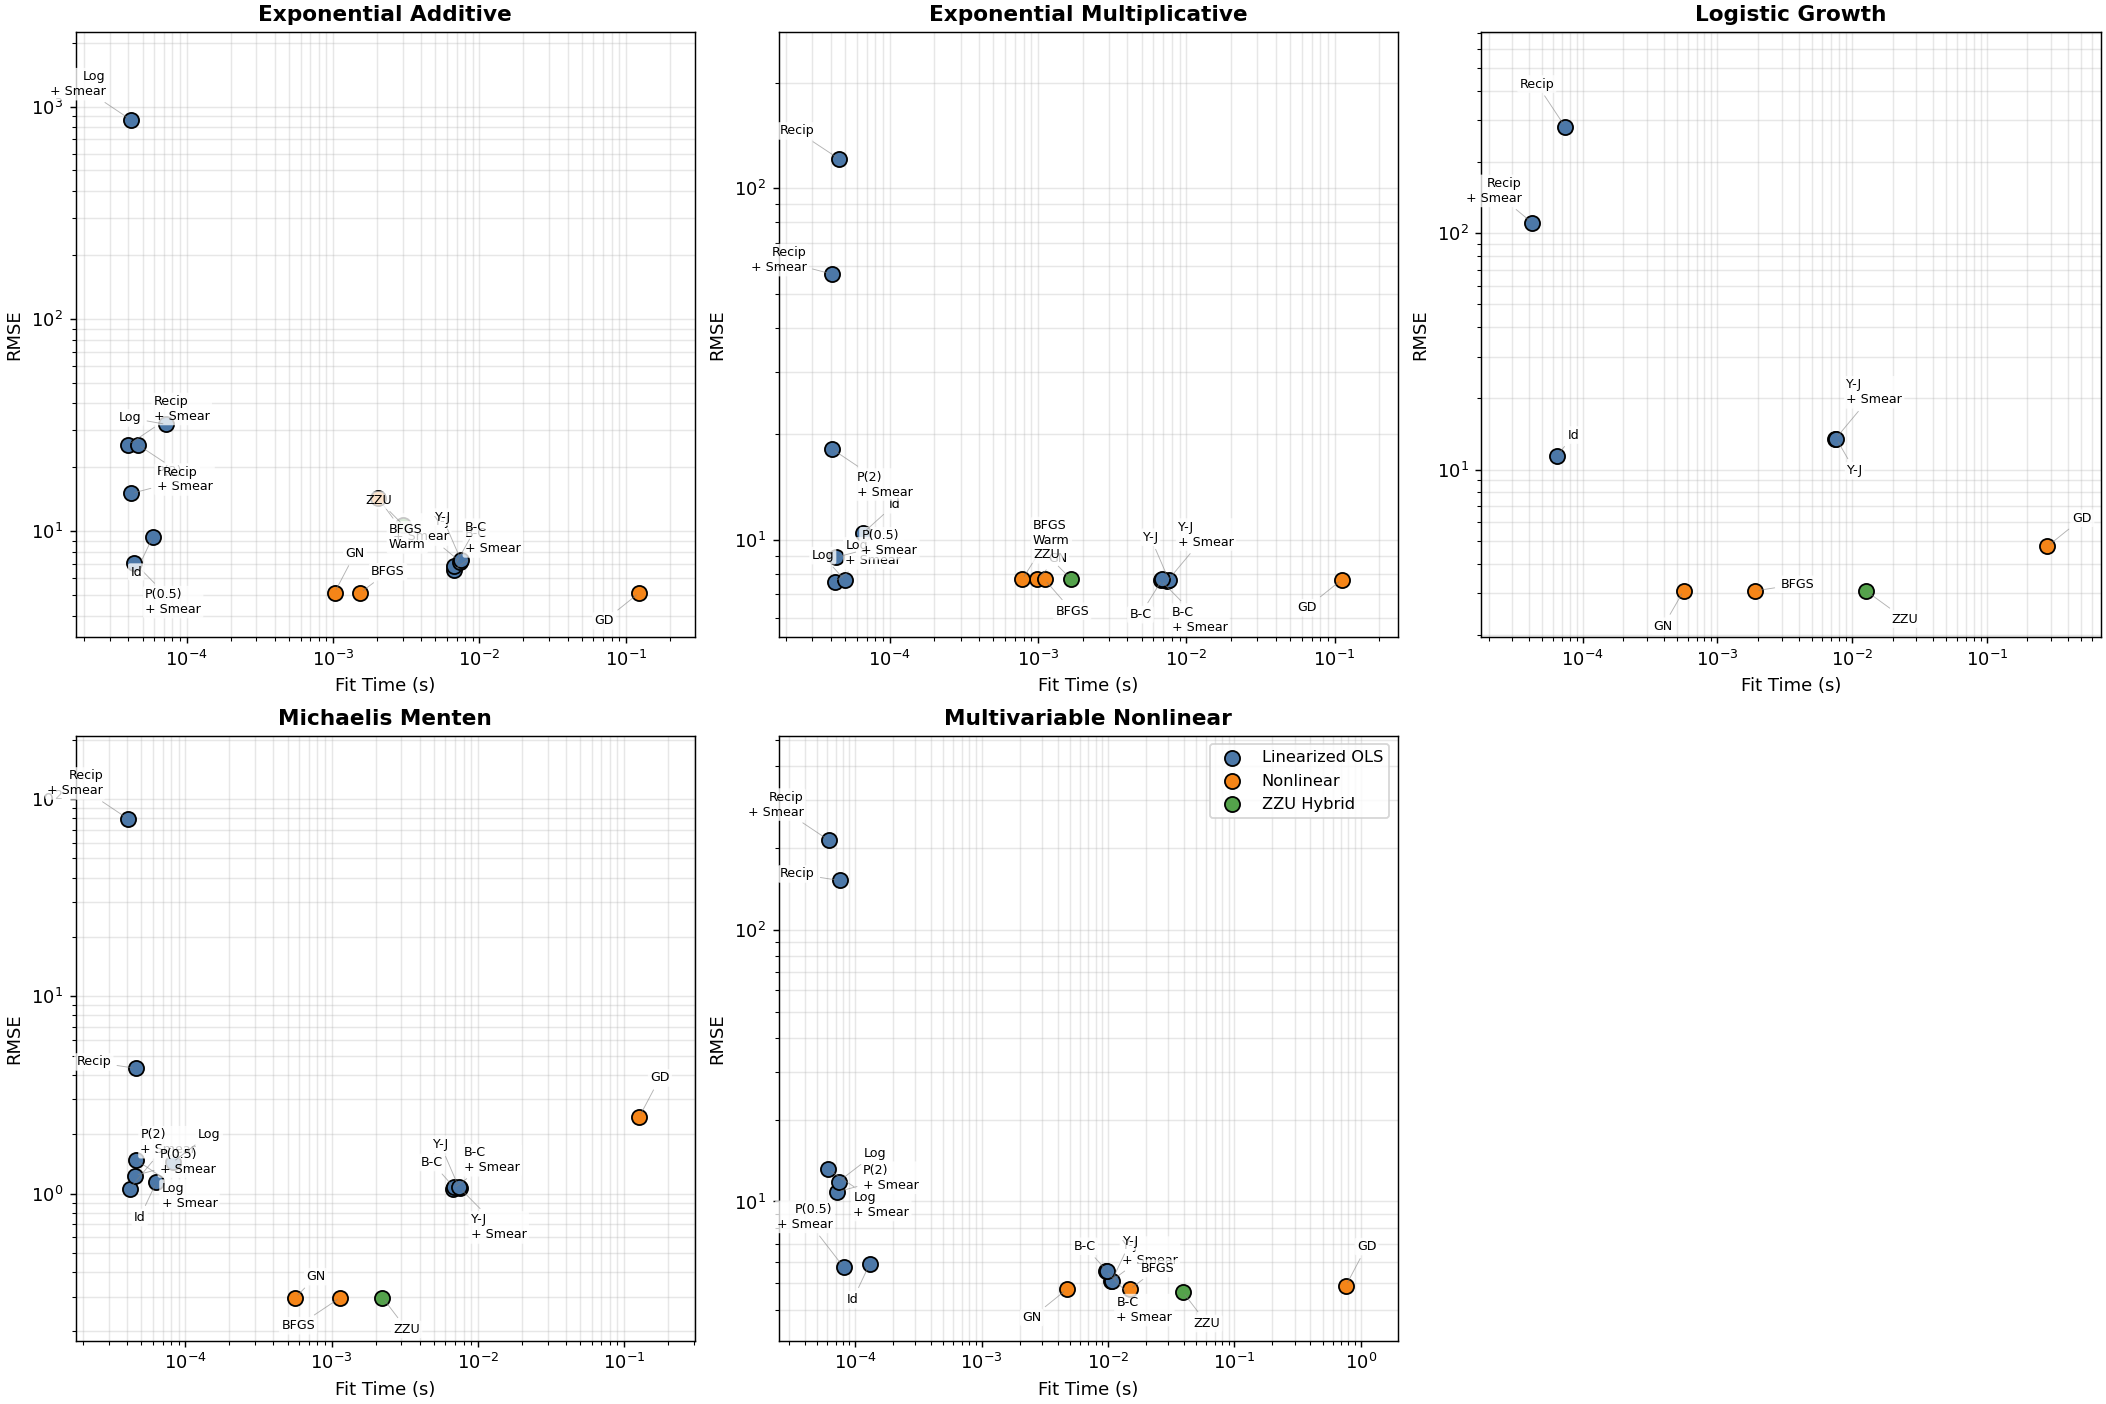

### Warm-start vs cold-start BFGS

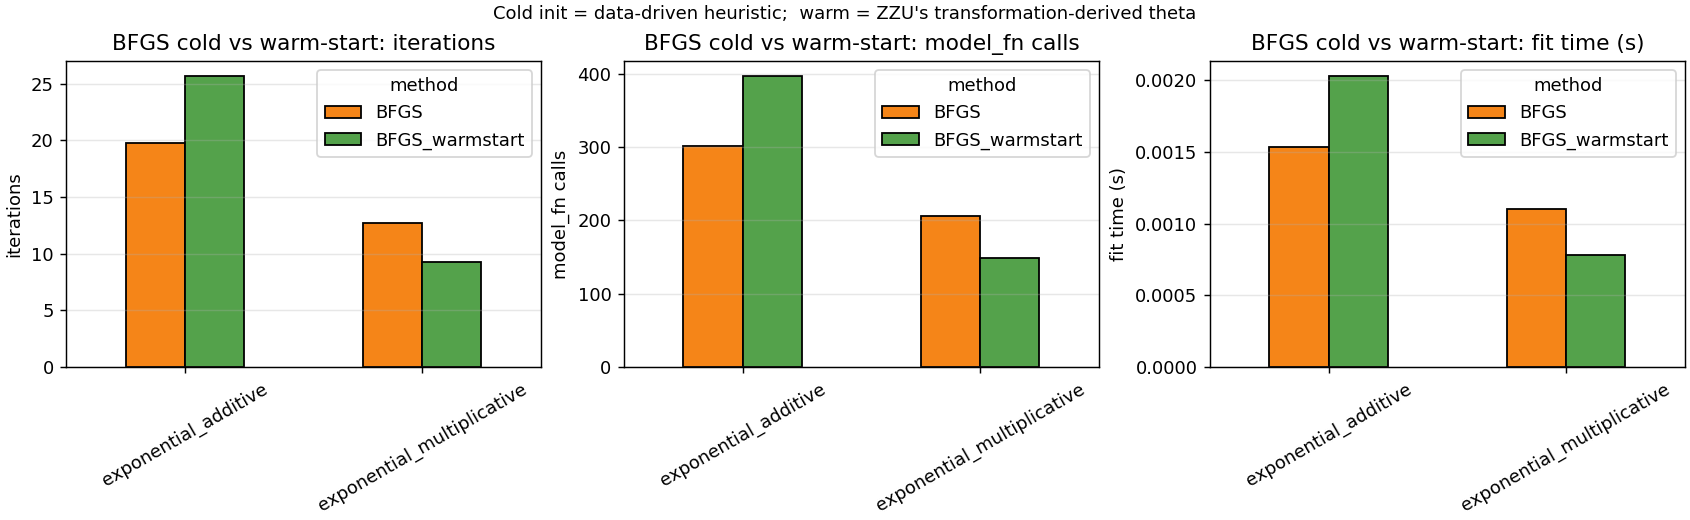

In [9]:
import cost_analysis
t0 = time.perf_counter()
cost_analysis.main()
print(f"\nElapsed: {time.perf_counter() - t0:.1f}s")

cost_summary = pd.read_csv(SANDBOX / "comparison_results" / "cost_summary.csv")
display(Markdown("### Cheapest 5 methods per dataset (mean fit time, asc)"))
for d in cost_summary.dataset.unique():
    sub = (cost_summary[(cost_summary.dataset == d) & cost_summary.mean_rmse.notna()]
           .nsmallest(5, "mean_fit_time_sec"))
    display(Markdown(f"**[{d}]**"))
    display(sub[["method","family","mean_rmse","mean_fit_time_sec",
                 "mean_n_iter","mean_n_model_evals"]].reset_index(drop=True))

display(Markdown("### Cost vs accuracy Pareto"))
display(Image(filename=str(SANDBOX / "comparison_results" / "cost_pareto.png")))

display(Markdown("### Warm-start vs cold-start BFGS"))
display(Image(filename=str(SANDBOX / "comparison_results" / "warm_vs_cold.png")))

## 10. ZZU inner-method ablation

For each dataset, six configurations: pure-GD / ZZU+GD / pure-GN / ZZU+GN / pure-BFGS / ZZU+BFGS. Verifies that ZZU's benefit is largely *independent of the inner optimizer*.

[exponential_multiplicative]
[exponential_additive]
[michaelis_menten]
[logistic_growth]
[multivariable_nonlinear]

Wrote 300 rows to zzu_inner_method_results.csv
Wrote summary to zzu_inner_method_summary.csv
Wrote plot:  zzu_inner_method.png

Mean RMSE / fit time / n_iter / convergence per (dataset, optimizer, variant):
                   dataset           method variant  mean_rmse  mean_fit_time  mean_n_iter  frac_converged
      exponential_additive             bfgs    pure   5.142041       0.001478    19.800000             1.0
      exponential_additive             bfgs     zzu  10.754055       0.002622    25.700000             1.0
      exponential_additive     gauss_newton    pure   5.142041       0.000941    23.400000             1.0
      exponential_additive     gauss_newton     zzu   5.122390       0.001698    26.000000             1.0
      exponential_additive gradient_descent    pure   5.136741       0.113476  5000.000000             0.0
      exponential_additive gradient

### Pure vs ZZU for each (dataset, inner optimizer)

,dataset,method,variant,mean_rmse,mean_fit_time,mean_n_iter,frac_converged
0,exponential_additive,bfgs,pure,5.142041,0.001478,19.800000,1.0
1,exponential_additive,bfgs,zzu,10.754055,0.002622,25.700000,1.0
2,exponential_additive,gauss_newton,pure,5.142041,0.000941,23.400000,1.0
3,exponential_additive,gauss_newton,zzu,5.122390,0.001698,26.000000,1.0
4,exponential_additive,gradient_descent,pure,5.136741,0.113476,5000.000000,0.0
5,exponential_additive,gradient_descent,zzu,17.603763,0.113397,5000.000000,0.0
6,exponential_multiplicative,bfgs,pure,7.701178,0.001051,12.700000,1.0
7,exponential_multiplicative,bfgs,zzu,7.706256,0.001457,9.300000,1.0
8,exponential_multiplicative,gauss_newton,pure,7.701178,0.000902,22.800000,1.0
9,exponential_multiplicative,gauss_newton,zzu,7.706256,0.000973,5.400000,1.0


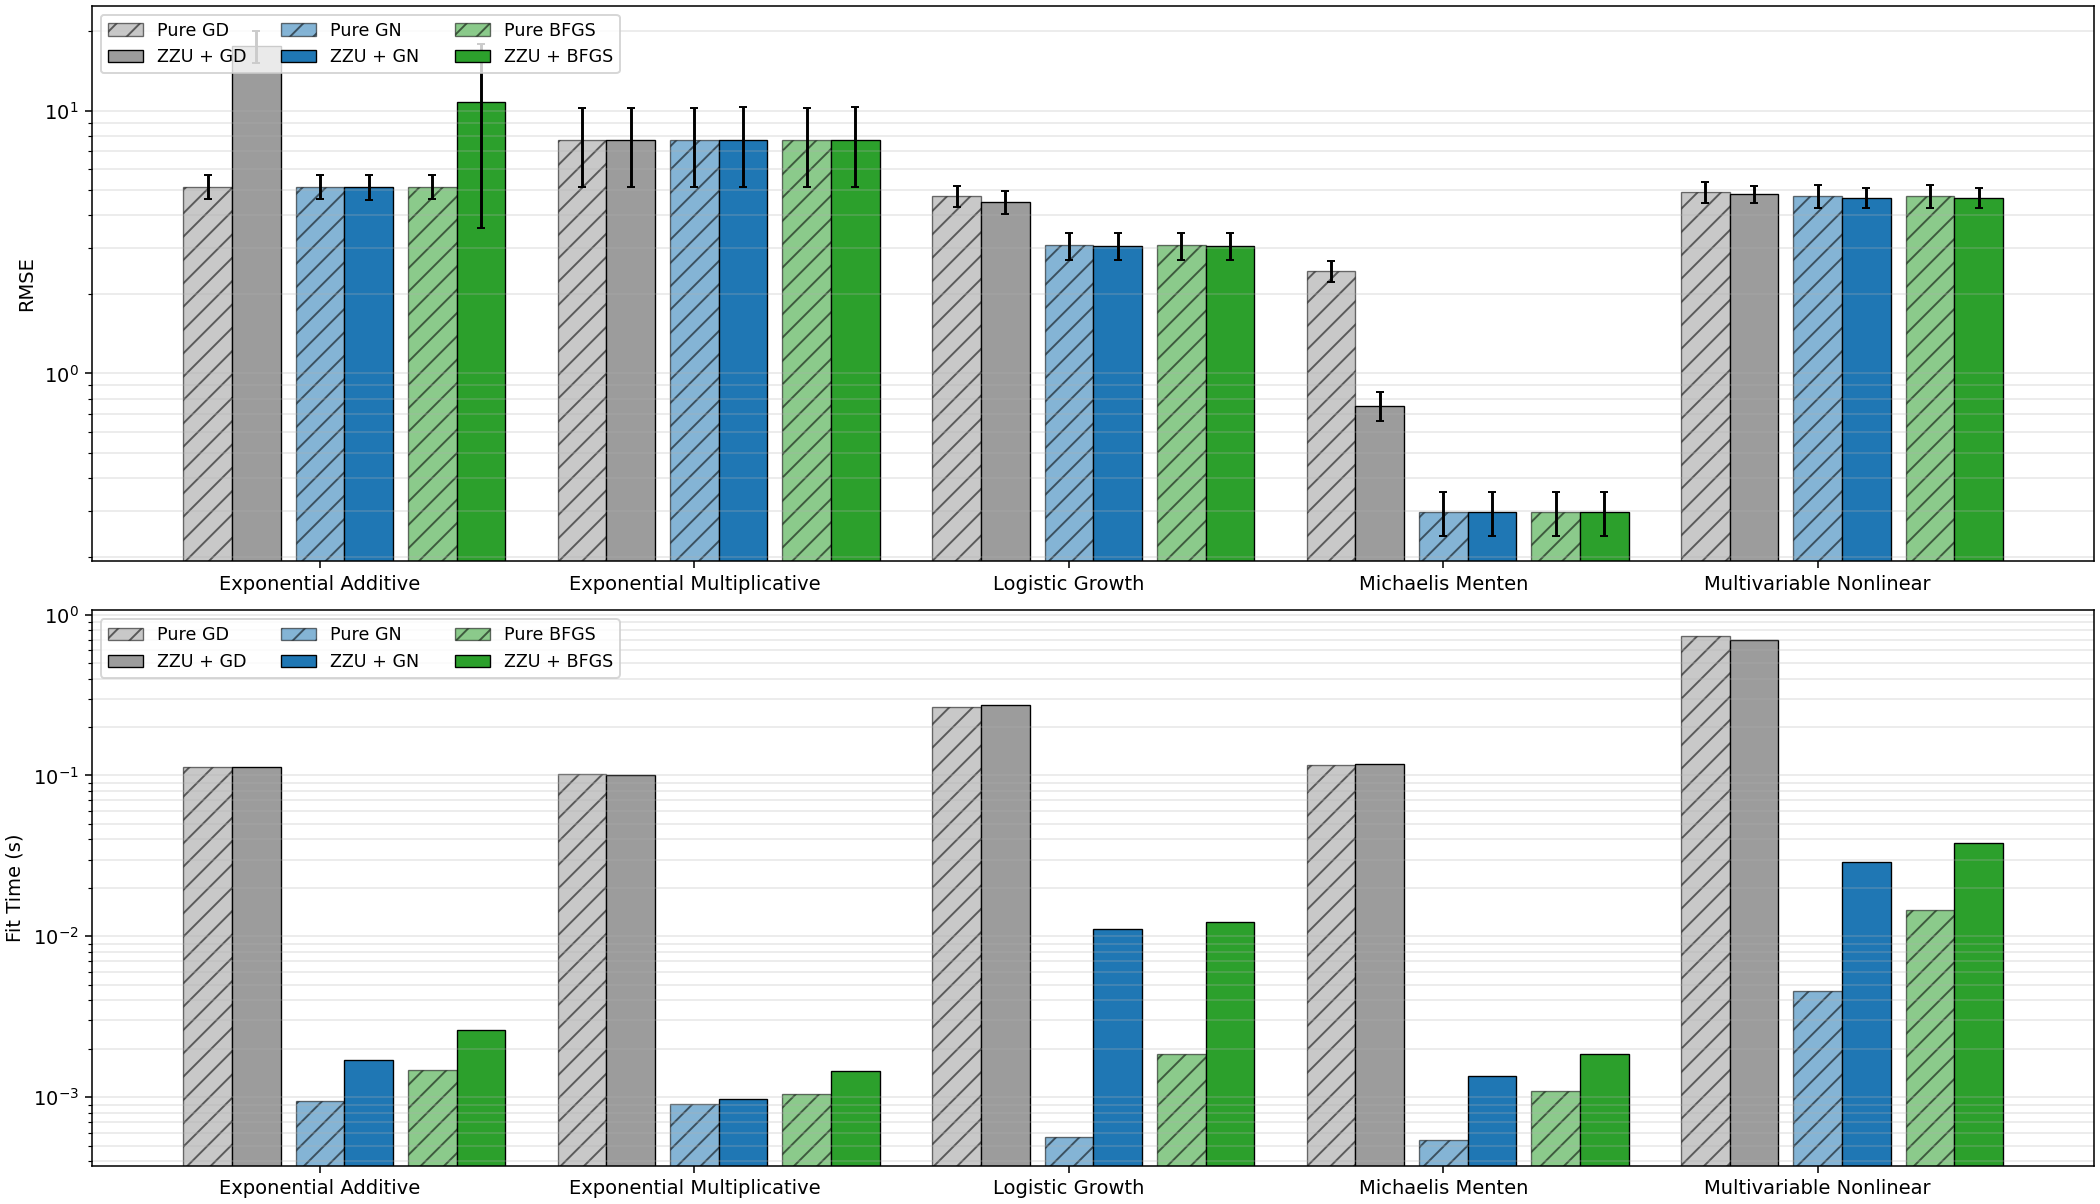

In [10]:
import zzu_inner_method_comparison
t0 = time.perf_counter()
zzu_inner_method_comparison.main()
print(f"\nElapsed: {time.perf_counter() - t0:.1f}s")

inner = pd.read_csv(SANDBOX / "comparison_results" / "zzu_inner_method_summary.csv")
display(Markdown("### Pure vs ZZU for each (dataset, inner optimizer)"))
display(inner[["dataset","method","variant","mean_rmse",
               "mean_fit_time","mean_n_iter","frac_converged"]].reset_index(drop=True))

display(Image(filename=str(SANDBOX / "comparison_results" / "zzu_inner_method.png")))

## 11. Test suite

158 pytest cases across 7 modules covering linear helpers, transforms, TransformedOLS, the three nonlinear optimizers, ZZU, toy-data generators, and end-to-end reproducibility. Run from the project root:

```bash
pytest tests/        # 158 passed
```

---

## What's next

Real-world dataset experiments are out of scope for this notebook. Two notebooks pick up from here:

- [concrete_analysis.ipynb](concrete_analysis.ipynb) — UCI Concrete Compressive Strength
- [bike_analysis.ipynb](bike_analysis.ipynb) — UCI Bike Sharing